In [1]:
#This code compresses PROCEDURES_ICD9, and DIAGNOSES_ICD9 into single entries per admission (sorted by SEQ_NUM)
#and merges this data with the ADMISSIONS dataframe, providing two separate dataframes with this merged structure.
#One dataframe corresponds to patients diagnosed with specified ICD-9 codes and the other contains the control patients.

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
import shap

PATIENTS = pd.read_csv("./PATIENTS.csv")
ADMISSIONS = pd.read_csv("./ADMISSIONS.csv")
DIAGNOSES_ICD = pd.read_csv("./DIAGNOSES_ICD.csv")
PROCEDURES_ICD = pd.read_csv("./PROCEDURES_ICD.csv")
ICD_9_Filtered = pd.read_csv("./ICD9_GEMINI_ANALYSIS.csv")
ICD_9_DESCRIPTIONS = pd.read_csv("./icd-9-comparison-excel-file.csv")
be_risk_factors = pd.read_csv("./be_risk_factor_codes.csv")
reduced_features = pd.read_csv("./top_reduced_features_2800_0.5_refined.csv")


  PHASE 1: FEATURE CLEANING & INITIALIZATION

[INFO] Unique features after Chi-Squared Filtering: 127

--------------------------------------------------
  PHASE 2: TARGET & CONTROL COHORT DEFINITION
--------------------------------------------------

[DATA] Total Unique Diagnoses: 6984
[DATA] Total Unique Procedures: 2009
[INFO] Patients excluded from controls: 16140

--------------------------------------------------
  PHASE 3: COMPRESSING TEMPORAL DATA
--------------------------------------------------


--------------------------------------------------
  PHASE 4: PRE-DIAGNOSTIC FILTERING & INDEXING
--------------------------------------------------

[RESULT] Cases with 1 prior admission: 39
[RESULT] Cases with 2+ prior admissions: 34

[PLOT] Saved 'cases_history_dist.png' to visualize diseased cohort history.

--------------------------------------------------
  PHASE 5: CONTROL SUBSAMPLING & GAPS
--------------------------------------------------


[FINAL] Cases: (153, 23) | Con

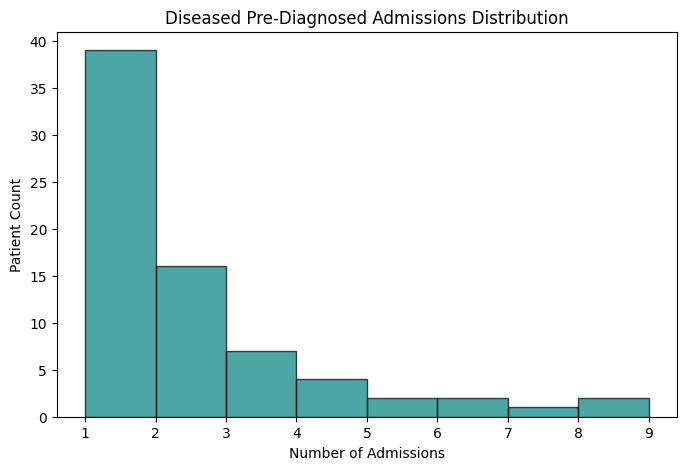

In [2]:
print("\n" + "="*50)
print("  PHASE 1: FEATURE CLEANING & INITIALIZATION")
print("="*50 + "\n")

# Cleaning feature labels from Chi-Squared selection
reduced_features['Feature'] = reduced_features['Feature'].apply(lambda x: x.split(':')[0] if isinstance(x, str) else x)
reduced_features['Feature'] = reduced_features['Feature'].apply(lambda x: x.split(' ', 1)[-1] if ' ' in str(x) else x)

print(f"[INFO] Unique features after Chi-Squared Filtering: {reduced_features['Feature'].nunique()}")

# Setup Patients and Random Seed
PATIENTS = PATIENTS[['SUBJECT_ID','DOB']]
PATIENTS['DOB'] = pd.to_datetime(PATIENTS['DOB'], errors='coerce')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("\n" + "-"*50)
print("  PHASE 2: TARGET & CONTROL COHORT DEFINITION")
print("-"*50 + "\n")

DIAGNOSES_ICD = DIAGNOSES_ICD.dropna(subset=['ICD9_CODE'])
PROCEDURES_ICD = PROCEDURES_ICD.dropna(subset=['ICD9_CODE'])

# Target: Bacterial Endocarditis
my_icd9_code = ['4210'] 
PROCEDURES_ICD['ICD9_CODE'] = PROCEDURES_ICD['ICD9_CODE'].astype(str).str.zfill(4)

# Merging descriptions for better readability in analysis
DIAGNOSES_ICD = DIAGNOSES_ICD.merge(ICD_9_DESCRIPTIONS[['ICD9','Description']], left_on='ICD9_CODE', right_on='ICD9', how='left')
PROCEDURES_ICD = PROCEDURES_ICD.merge(ICD_9_DESCRIPTIONS[['ICD9','Description']], left_on='ICD9_CODE', right_on='ICD9', how='left')

# Format ICD9_FULL as 'Code: Description'
for df in [DIAGNOSES_ICD, PROCEDURES_ICD]:
    df['ICD9_FULL'] = df['ICD9_CODE']
    mask = (df['Description'].notna()) & (df['Description'] != '')
    df.loc[mask, 'ICD9_FULL'] = df['ICD9_CODE'] + ": " + df['Description']
    df.drop(columns=['ICD9', 'Description'], inplace=True)

print(f"[DATA] Total Unique Diagnoses: {DIAGNOSES_ICD['ICD9_CODE'].nunique()}")
print(f"[DATA] Total Unique Procedures: {PROCEDURES_ICD['ICD9_CODE'].nunique()}")

# Identify Cases (ICD-9 + Text Search)
DISEASE_SUBJECT_ID = DIAGNOSES_ICD.loc[DIAGNOSES_ICD["ICD9_CODE"].isin(my_icd9_code), "SUBJECT_ID"].unique()
disease_text_ids = ADMISSIONS[ADMISSIONS['DIAGNOSIS'].str.contains('BACTERIAL ENDOCARDITIS', na=False)]['SUBJECT_ID'].unique()
EXCLUDE_FROM_CONTROLS = np.union1d(DISEASE_SUBJECT_ID, disease_text_ids)

# Crisis code exclusion
easy_and_crisis_codes = ['99592', '51881', '0389', '78552', '5849', '03811', '03842', '78551', '4275', '51884', '9671', '9672', '9604', '4241']
crashing_controls = DIAGNOSES_ICD[DIAGNOSES_ICD['ICD9_CODE'].isin(easy_and_crisis_codes)]['SUBJECT_ID'].unique()
EXCLUDE_FROM_CONTROLS = np.union1d(EXCLUDE_FROM_CONTROLS, crashing_controls)

CONTROL_SUBJECT_ID = DIAGNOSES_ICD.loc[~DIAGNOSES_ICD["SUBJECT_ID"].isin(EXCLUDE_FROM_CONTROLS), "SUBJECT_ID"].unique()
DISEASE_HADM_ID = DIAGNOSES_ICD.loc[DIAGNOSES_ICD["ICD9_CODE"].isin(my_icd9_code), "HADM_ID"].unique()

print(f"[INFO] Patients excluded from controls: {len(EXCLUDE_FROM_CONTROLS)}")

print("\n" + "-"*50)
print("  PHASE 3: COMPRESSING TEMPORAL DATA")
print("-"*50 + "\n")

# Filter by Chi-Squared features and minimum prevalence (>7)
DIAGNOSES_ICD = DIAGNOSES_ICD[DIAGNOSES_ICD['ICD9_CODE'].isin(reduced_features['Feature'])]
PROCEDURES_ICD = PROCEDURES_ICD[PROCEDURES_ICD['ICD9_CODE'].isin(reduced_features['Feature'])]
DIAGNOSES_ICD = DIAGNOSES_ICD.groupby('ICD9_CODE').filter(lambda x: x['SUBJECT_ID'].nunique() > 7)

# Grouping codes into lists per admission
def compress_codes(df, sub_ids, col_name):
    filtered = df[df['SUBJECT_ID'].isin(sub_ids)]
    if col_name == 'DIAGNOSES':
        filtered = filtered[~filtered['ICD9_CODE'].isin(my_icd9_code)]
    return filtered.sort_values(['HADM_ID','SEQ_NUM']).groupby(['SUBJECT_ID','HADM_ID'])['ICD9_FULL'].apply(list).reset_index(name=col_name)

PATIENT_DIAGNOSES = compress_codes(DIAGNOSES_ICD, DISEASE_SUBJECT_ID, 'DIAGNOSES')
CONTROL_DIAGNOSES = compress_codes(DIAGNOSES_ICD, CONTROL_SUBJECT_ID, 'DIAGNOSES')
PATIENT_PROCEDURES = compress_codes(PROCEDURES_ICD, DISEASE_SUBJECT_ID, 'PROCEDURE TYPE')
CONTROL_PROCEDURES = compress_codes(PROCEDURES_ICD, CONTROL_SUBJECT_ID, 'PROCEDURE TYPE')

# Merging into Admission master tables
PATIENT_ADMISSIONS_MERGED = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(DISEASE_SUBJECT_ID)]\
    .merge(PATIENT_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENT_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENTS, on=["SUBJECT_ID"], how="left")

CONTROL_ADMISSIONS_MERGED = ADMISSIONS[ADMISSIONS['SUBJECT_ID'].isin(CONTROL_SUBJECT_ID)]\
    .merge(CONTROL_DIAGNOSES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(CONTROL_PROCEDURES, on=["HADM_ID","SUBJECT_ID"], how="left")\
    .merge(PATIENTS, on=["SUBJECT_ID"], how="left")

for df in [PATIENT_ADMISSIONS_MERGED, CONTROL_ADMISSIONS_MERGED]:
    df.rename(columns={"DIAGNOSIS": "DIAGNOSIS (LABEL)","DIAGNOSES": "DIAGNOSIS (ICD_9)"}, inplace=True)
    if 'ROW_ID' in df.columns: df.drop(['ROW_ID'], axis=1, inplace=True)
    df['ADMITTIME'] = pd.to_datetime(df["ADMITTIME"], errors="coerce")

print("\n" + "-"*50)
print("  PHASE 4: PRE-DIAGNOSTIC FILTERING & INDEXING")
print("-"*50 + "\n")

# Find first diagnosis time for cases
DISEASE_FIRST_ADMISSIONS = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['HADM_ID'].isin(DISEASE_HADM_ID)]\
    .groupby('SUBJECT_ID', as_index=False)['ADMITTIME'].min().rename(columns={"ADMITTIME": "Comparator"})

# Restrict cases to history BEFORE the diagnosis
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED.merge(DISEASE_FIRST_ADMISSIONS, on='SUBJECT_ID', how="left")
PATIENT_ADMISSIONS_MERGED = PATIENT_ADMISSIONS_MERGED[PATIENT_ADMISSIONS_MERGED['ADMITTIME'] < PATIENT_ADMISSIONS_MERGED['Comparator']]
PATIENT_ADMISSIONS_MERGED.drop(['Comparator'], axis=1, inplace=True)

# Sorting and event indexing (T-1, T-2...)
for df in [PATIENT_ADMISSIONS_MERGED, CONTROL_ADMISSIONS_MERGED]:
    df.sort_values(['SUBJECT_ID', 'ADMITTIME'], ascending=[True, False], inplace=True)
    df['event_index'] = (df.groupby('SUBJECT_ID').cumcount() + 1) * -1

diseased_counts = PATIENT_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()
print(f"[RESULT] Cases with 1 prior admission: {(diseased_counts == 1).sum()}")
print(f"[RESULT] Cases with 2+ prior admissions: {(diseased_counts >= 2).sum()}")

# Plotting Admission Distribution
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(diseased_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
ax.set_title('Diseased Pre-Diagnosed Admissions Distribution')
ax.set_xlabel('Number of Admissions')
ax.set_ylabel('Patient Count')
plt.savefig('cases_history_dist.png')
print("\n[PLOT] Saved 'cases_history_dist.png' to visualize diseased cohort history.")

print("\n" + "-"*50)
print("  PHASE 5: CONTROL SUBSAMPLING & GAPS")
print("-"*50 + "\n")

# We are matching the ratio of single admission patients to double admission patients for the controls group, based on the ratio found in the diseased group to reduce single admissions in controls which
# likely represent milder patient phenotypes
diseased_1, diseased_2 = (diseased_counts == 1).sum(), (diseased_counts == 2).sum()
control_counts = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()
num_to_keep = round(diseased_1/diseased_2 * (control_counts == 2).sum())

c_ids_1 = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID').filter(lambda x: x['HADM_ID'].nunique() == 1)['SUBJECT_ID'].unique()
sampled_c1_ids = np.random.choice(c_ids_1, size=num_to_keep, replace=False)
c_ids_multi = control_counts[(control_counts >= 2) & (control_counts < 9)].index

CONTROL_SUBJECT_ID = np.concatenate([sampled_c1_ids, c_ids_multi])

CONTROL_ADMISSIONS_MERGED = CONTROL_ADMISSIONS_MERGED[CONTROL_ADMISSIONS_MERGED['SUBJECT_ID'].isin(np.concatenate([sampled_c1_ids, c_ids_multi]))]
reduced_control_counts = CONTROL_ADMISSIONS_MERGED.groupby('SUBJECT_ID')['HADM_ID'].nunique()

# Final Gap Calculations
for df, label in [(PATIENT_ADMISSIONS_MERGED, 'Cases'), (CONTROL_ADMISSIONS_MERGED, 'Controls')]:
    if label == 'Cases':
        df['Gap'] = df.groupby(['SUBJECT_ID'])['ADMITTIME'].diff(periods=-1).abs().dt.days
    else:
        df['Gap'] = df.groupby('SUBJECT_ID')['ADMITTIME'].diff(periods=1).dt.days.abs()
    
    df['Recent Admission Gaps'] = df.groupby('SUBJECT_ID')['Gap'].transform('last').fillna(3650)
    df.drop(columns=['Gap'], inplace=True)

print(f"\n[FINAL] Cases: {PATIENT_ADMISSIONS_MERGED.shape} | Controls: {CONTROL_ADMISSIONS_MERGED.shape}")
print("\n" + "="*50)
print("  CHUNK 1 COMPLETE")
print("="*50 + "\n")

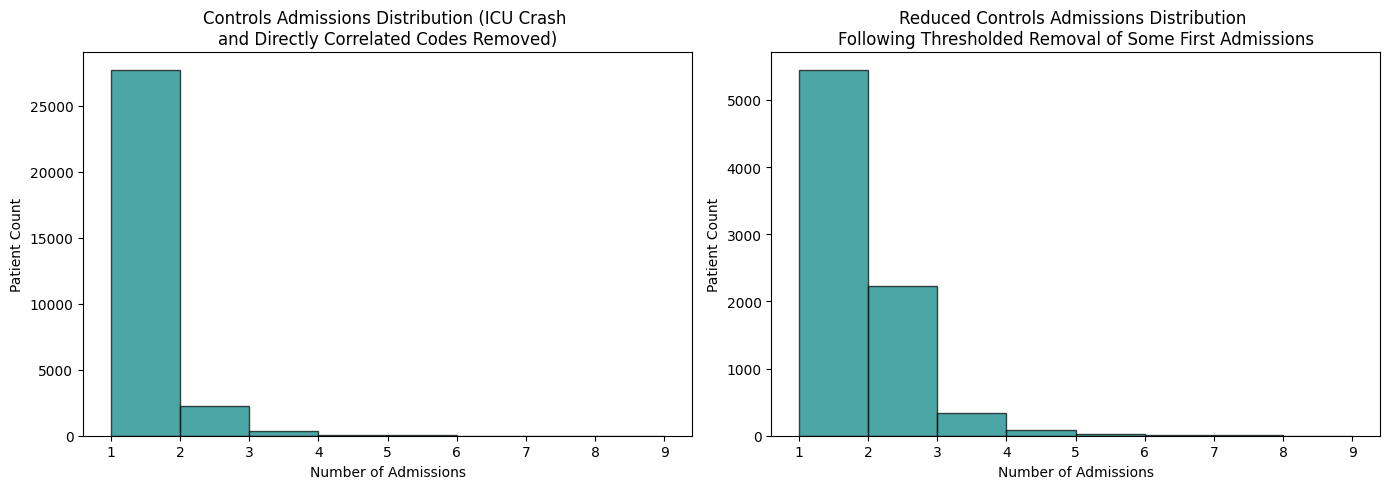


[PLOT] Saved and displayed side-by-side admission history distributions.


In [3]:
# Create a figure with 1 row and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plotting the first (left) distribution
axs[0].hist(control_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
axs[0].set_title('Controls Admissions Distribution (ICU Crash \nand Directly Correlated Codes Removed)')
axs[0].set_xlabel('Number of Admissions')
axs[0].set_ylabel('Patient Count')

# Plotting the second (right) distribution (identical copy)
axs[1].hist(reduced_control_counts, bins=range(1, 10), alpha=0.7, color='teal', edgecolor='black')
axs[1].set_title('Reduced Controls Admissions Distribution \nFollowing Thresholded Removal of Some First Admissions')
axs[1].set_xlabel('Number of Admissions')
axs[1].set_ylabel('Patient Count')

plt.tight_layout()
plt.savefig('cases_history_dist_dual.png')
plt.show() # Ensures visibility in Jupyter Notebook

print("\n[PLOT] Saved and displayed side-by-side admission history distributions.")

In [4]:
# --- ENHANCED CHUNK 2 (FORMATTED) ---
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt

print("\n" + "="*50)
print("  PHASE 6: CLINICAL DATA PREPROCESSING & CLEANING")
print("="*50 + "\n")

def preprocess_clinical_data(df):
    df = df.copy()
    
    # Calculate length of stay in days
    df['ADMITTIME'] = pd.to_datetime(df['ADMITTIME'])
    df['DISCHTIME'] = pd.to_datetime(df['DISCHTIME'])
    df['LOS_DAYS'] = round((df['DISCHTIME'] - df['ADMITTIME']).dt.total_seconds() / 86400)
    
    # Calculate Age and cap elderly at 92, drop newborns
    df['Age'] = (df['ADMITTIME'] - df['DOB']).dt.days // 365
    df.loc[df['Age'] > 100, 'Age'] = 92 
    
    initial_rows = len(df)
    df = df[df['Age'] > 0] 
    dropped_newborns = initial_rows - len(df)
    
    # Define Leaky/Identifier columns to drop
    cols_to_drop = [
        'HADM_ID', 'ADMITTIME', 'DISCHTIME', 
        'DEATHTIME', 'EDREGTIME', 'EDOUTTIME', 'HOSPITAL_EXPIRE_FLAG',
        'DIAGNOSIS (LABEL)', 'HAS_CHARTEVENTS_DATA','DOB'
    ]

    # Drop columns if they exist in the dataframe
    existing_drops = [c for c in cols_to_drop if c in df.columns]
    df_clean = df.drop(columns=existing_drops)
    
    return df_clean, dropped_newborns, existing_drops

print("[INFO] Cleaning Patient Data...")
PATIENT_CLEAN, p_dropped, p_cols = preprocess_clinical_data(PATIENT_ADMISSIONS_MERGED)
print(f"[RESULT] Dropped {p_dropped} newborn records. Removed {len(p_cols)} leaky columns.")

print("[INFO] Cleaning Control Data...")
CONTROL_CLEAN, c_dropped, c_cols = preprocess_clinical_data(CONTROL_ADMISSIONS_MERGED)
print(f"[RESULT] Dropped {c_dropped} newborn records. Removed {len(c_cols)} leaky columns.")

print("\n" + "-"*50)
print("  PHASE 7: TEMPORAL FEATURE ENGINEERING")
print("-"*50 + "\n")


  PHASE 6: CLINICAL DATA PREPROCESSING & CLEANING

[INFO] Cleaning Patient Data...
[RESULT] Dropped 0 newborn records. Removed 10 leaky columns.
[INFO] Cleaning Control Data...
[RESULT] Dropped 1961 newborn records. Removed 10 leaky columns.

--------------------------------------------------
  PHASE 7: TEMPORAL FEATURE ENGINEERING
--------------------------------------------------



In [5]:
def prepare_patient_level_features(PATIENT_CLEAN, CONTROL_CLEAN):
    from collections import Counter

    # Combine everything into one DF to ensure columns align across all patients
    df = pd.concat([PATIENT_CLEAN, CONTROL_CLEAN], axis=0)

    # Attach event index to code to retain temporal sequence structure (e.g., "T-1 4210")
    def prefix_codes(row, col_name):
        codes = row[col_name]
        if not isinstance(codes, list): return []
        return [f"T{int(row['event_index'])} {code}" for code in codes]

    df['diag_temporal'] = df.apply(lambda x: prefix_codes(x, 'DIAGNOSIS (ICD_9)'), axis=1)
    df['proc_temporal'] = df.apply(lambda x: prefix_codes(x, 'PROCEDURE TYPE'), axis=1)

    # Concatenate temporal codes and demographic maxs into a single row per patient
    patient_df = df.groupby('SUBJECT_ID').agg({
        'diag_temporal': 'sum',
        'proc_temporal': 'sum',
        'LOS_DAYS': 'max',
        'Age': 'max'
    }).sort_index()
    
    # Calculate prevalence specific to our cases and controls subsets
    be_patients_only = patient_df.loc[patient_df.index.isin(DISEASE_SUBJECT_ID)]
    controls_patients_only = patient_df.loc[patient_df.index.isin(CONTROL_SUBJECT_ID)]

    all_be_codes = [code for sublist in be_patients_only['diag_temporal'].apply(set) for code in sublist]
    all_controls_codes = [code for sublist in controls_patients_only['diag_temporal'].apply(set) for code in sublist]

    be_prevalence = (pd.Series(Counter(all_be_codes))).sort_values(ascending=False)
    controls_prevalence = (pd.Series(Counter(all_controls_codes))).sort_values(ascending=False)

    # Impute NAs for numericals
    X_num = patient_df[['LOS_DAYS', 'Age']].fillna(0)    
  
    return X_num, patient_df['diag_temporal'], patient_df['proc_temporal'], patient_df.index, df, be_prevalence, controls_prevalence

num_f, diag_list, proc_list, patient_ids, full_df, be_prevalence, controls_prevalence = prepare_patient_level_features(PATIENT_CLEAN, CONTROL_CLEAN)

print(f"[INFO] Temporal prefixes applied. Extracted features for {len(patient_ids)} total unique patients.")

# ----------------------------------

print("\n" + "-"*50)
print("  PHASE 8: MATRIX VECTORIZATION (ONE-HOT ENCODING)")
print("-"*50 + "\n")

# Prepare sparse one-hot encoding for massive feature lists
mlb_diag = MultiLabelBinarizer(sparse_output=True).fit(diag_list)
mlb_proc = MultiLabelBinarizer(sparse_output=True).fit(proc_list)

print(f"[MATRIX] Transformed Diagnoses into {len(mlb_diag.classes_)} unique features.")
print(f"[MATRIX] Transformed Procedures into {len(mlb_proc.classes_)} unique features.")
print(f"[MATRIX] Numerical Features length: {num_f.shape[1]}")

# Stack all feature matrices horizontally
X_sparse = hstack([
    mlb_diag.transform(diag_list),
    mlb_proc.transform(proc_list),
    csr_matrix(num_f.astype(float))
])

# Create binary target array
y = np.array([1 if pid in DISEASE_SUBJECT_ID else 0 for pid in patient_ids])

print("\n" + "="*50)
print("  CHUNK 2 COMPLETE: FINAL MODELING SET READY")
print("="*50)
print(f"Final Patient-Level X Matrix Shape: {X_sparse.shape}")
print(f"Target Array (y) Shape: {y.shape}")
print(f"Class Balance -> Total Patients: {len(y)} | Diseased Cases: {sum(y)} | Controls: {len(y) - sum(y)}\n")


[INFO] Temporal prefixes applied. Extracted features for 6479 total unique patients.

--------------------------------------------------
  PHASE 8: MATRIX VECTORIZATION (ONE-HOT ENCODING)
--------------------------------------------------

[MATRIX] Transformed Diagnoses into 439 unique features.
[MATRIX] Transformed Procedures into 187 unique features.
[MATRIX] Numerical Features length: 2

  CHUNK 2 COMPLETE: FINAL MODELING SET READY
Final Patient-Level X Matrix Shape: (6479, 628)
Target Array (y) Shape: (6479,)
Class Balance -> Total Patients: 6479 | Diseased Cases: 73 | Controls: 6406



In [6]:
print("Actual BE Patient Profile:\n", be_prevalence.head(15))

Actual BE Patient Profile:
 T-1 4280: CHF NOS                      33
T-1 42731: Atrial fibrillation         26
T-1 41401: Crnry athrscl natve vssl    20
T-2 42731: Atrial fibrillation         16
T-2 40391: Hyp kid NOS w cr kid V      12
T-1 5849: Acute kidney failure NOS     12
T-1 40391: Hyp kid NOS w cr kid V      12
T-1 V5861: Long-term use anticoagul    11
T-1 4241: Aortic valve disorder        11
T-2 4280: CHF NOS                      11
T-3 42731: Atrial fibrillation         10
T-1 5856: End stage renal disease      10
T-2 41401: Crnry athrscl natve vssl     9
T-1 51881: Acute respiratry failure     9
T-3 40391: Hyp kid NOS w cr kid V       9
dtype: int64


In [7]:
print("Controls Patient Profile:\n", controls_prevalence.head(15))

Controls Patient Profile:
 T-1 41401: Crnry athrscl natve vssl    1571
T-1 42731: Atrial fibrillation         1319
T-1 4280: CHF NOS                      1008
T-1 2720: Pure hypercholesterolem       870
T-1 53081: Esophageal reflux            851
T-1 5990: Urin tract infection NOS      593
T-2 41401: Crnry athrscl natve vssl     585
T-1 2859: Anemia NOS                    540
T-2 42731: Atrial fibrillation          480
T-1 V5861: Long-term use anticoagul     436
T-1 311: Depressive disorder NEC        431
T-1 311: Cutaneous mycobacteria         431
T-2 4280: CHF NOS                       410
T-2 2720: Pure hypercholesterolem       318
T-2 53081: Esophageal reflux            308
dtype: int64


In [ ]:
# --- ENHANCED CHUNK 3 (FORMATTED) ---
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.preprocessing import MaxAbsScaler
from sklearn.feature_selection import chi2
import shap
import math

print("\n" + "="*50)
print("  PHASE 8: MODEL TRAINING & CROSS-VALIDATION")
print("="*50 + "\n")

all_xgb, all_tree, all_lasso, all_chi, fold_metrics = [], [], [], [], []
all_probs, all_y = [], []
all_X_te_dfs = []

control_sample_size = 2800
seed_count = max(1, math.ceil(len(CONTROL_ADMISSIONS_MERGED['SUBJECT_ID'].unique()) / control_sample_size))

feat_names = [f"DX_{c}" for c in mlb_diag.classes_] + [f"PR_{c}" for c in mlb_proc.classes_] + ['LOS_DAYS','Age']

print(f"[INFO] Preparing to run {seed_count} random seed iterations.")
print(f"[INFO] Control sample size per iteration: {control_sample_size}")

# 1. Initialize global lists outside the loops
all_xgb_dfs, all_tree_dfs, all_lasso_dfs, all_chi_dfs = [], [], [], []
all_shap_dfs, all_shap_lasso_dfs = [], []

for seed in range(seed_count):
    importances_chi = []
    rng = np.random.default_rng(seed)
    sampled_control_ids = rng.choice(CONTROL_SUBJECT_ID, size=control_sample_size, replace=False)

    # Setup list of IDs to keep for this iteration
    keep_ids = np.concatenate([DISEASE_SUBJECT_ID, sampled_control_ids])
    mask = np.isin(patient_ids, keep_ids)

    X_sparse_seed = X_sparse[mask]
    y_seed = y[mask]

    importances_xgb, importances_tree, importances_lasso = [], [], []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    
    print("\n" + "-"*40)
    print(f"  SEED ITERATION {seed + 1}/{seed_count}")
    print("-"*40)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sparse_seed, y_seed)):
        #using MaxAbsScaler instead of StandardScaler so mean isn't centered at 0 causing negative values crashing chi-squared
        scaler = MaxAbsScaler()

        #pulling sparse matrices for this fold
        X_tr, X_te = X_sparse_seed[train_idx], X_sparse_seed[test_idx]
        y_tr, y_te = y_seed[train_idx], y_seed[test_idx]

        #converting to dense array restoring 0s
        X_tr = X_tr.toarray()
        X_te = X_te.toarray()

        #removing non-zero columns to prevent label leakage
        nonzero_cols = X_tr.sum(axis=0) > 0
        X_tr = X_tr[:, nonzero_cols]
        X_te = X_te[:, nonzero_cols]

        current_feat_names = np.array(feat_names)[nonzero_cols]

        cols = [i for i, f in enumerate(current_feat_names) if f in ['LOS_DAYS','Age']]

        if cols:
            X_tr[:, cols] = scaler.fit_transform(X_tr[:, cols])
            X_te[:, cols] = scaler.transform(X_te[:, cols])

        #performing chi value analysis on training data for later feature analysis. Features are in same order as training matrix
        chi_vals, chi_p = chi2(X_tr, y_tr) 
        
        # Track class balance before and after OverSampling
        cases_before = sum(y_tr)
        controls_before = len(y_tr) - cases_before
        
        # From 73 diseased patients to 1/2 of controls in this fold after patient duplication
        ros = RandomOverSampler(random_state=seed, sampling_strategy=0.2)
        
        #apply oversampling only to training data to prevent leakage into test data. Identifies rows in y_tr with a 1 and duplicates them
        X_tr, y_tr = ros.fit_resample(X_tr, y_tr)
        
        #for comparing before vs after oversampling
        cases_after = sum(y_tr)
        controls_after = len(y_tr) - cases_after

        # XGBoost
        xgb = XGBClassifier(
            n_estimators=500, 
            learning_rate=0.05, 
            max_depth=3, 
            random_state=seed, 
            eval_metric='logloss'
        )
        xgb.fit(X_tr, y_tr)

        #creating list of shap value lists
        explainer = shap.TreeExplainer(xgb)
        
        # Sensitivity and Specificity calculations
        probs = xgb.predict_proba(X_te)[:, 1]

        all_y.extend(y_te.tolist())
        all_probs.extend(probs.tolist())

        preds = xgb.predict(X_te)
        auc = roc_auc_score(y_te, probs)
        tn, fp, fn, tp = confusion_matrix(y_te, preds).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        fold_metrics.append({'Seed': seed, 'Fold': fold+1, 'AUC': auc, 'Sens': sens, 'Spec': spec})
        
        # Decision Tree
        dt = DecisionTreeClassifier(max_depth=5, random_state=42)
        dt.fit(X_tr, y_tr)

        # Lasso / Logistic Regression
        lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=42)
        lasso.fit(X_tr, y_tr)
        importances_lasso.append(np.abs(lasso.coef_[0]))

        explainer_lasso = shap.LinearExplainer(lasso, X_tr)

        all_xgb_dfs.append(pd.DataFrame([xgb.feature_importances_], columns=current_feat_names))
        all_tree_dfs.append(pd.DataFrame([dt.feature_importances_], columns=current_feat_names))
        all_lasso_dfs.append(pd.DataFrame([np.abs(lasso.coef_[0])], columns=current_feat_names))
        all_chi_dfs.append(pd.DataFrame([chi_vals], columns=current_feat_names))

        xgb_sv = explainer(X_te).values
        lasso_sv = explainer_lasso.shap_values(X_te)
        if isinstance(lasso_sv, list): lasso_sv = lasso_sv[1]

        all_shap_dfs.append(pd.DataFrame(np.asarray(xgb_sv), columns=current_feat_names))
        all_shap_lasso_dfs.append(pd.DataFrame(np.asarray(lasso_sv), columns=current_feat_names))
        all_X_te_dfs.append(pd.DataFrame(X_te, columns=current_feat_names))

        print(f"Fold {fold+1} | "
              f"ROS: Cases ({cases_before}->{cases_after}), Controls ({controls_before}->{controls_after}) | "
              f"AUC: {auc:.3f} | Sens: {sens:.1%} | Spec: {spec:.1%}")

master_xgb = pd.concat(all_xgb_dfs).mean().fillna(0)
master_chi = pd.concat(all_chi_dfs).mean().fillna(0)
master_lasso = pd.concat(all_lasso_dfs).mean().fillna(0)
master_tree = pd.concat(all_tree_dfs).mean().fillna(0)

final_X_te_df = pd.concat(all_X_te_dfs).fillna(0)
final_shap_df = pd.concat(all_shap_dfs).reindex(columns=final_X_te_df.columns).fillna(0)
final_shap_lasso_df = pd.concat(all_shap_lasso_dfs).reindex(columns=final_X_te_df.columns).fillna(0)

print("\n" + "="*50)
print("  PHASE 9: RESULTS AGGREGATION & FEATURE IMPORTANCE")
print("="*50 + "\n")

print("--- FINAL MEAN METRICS (XGBoost) ---")
print(pd.DataFrame(fold_metrics)[['AUC', 'Sens', 'Spec']].mean())

master_feat_df = pd.DataFrame({
    'XGBoost': master_xgb,
    'DecisionTree': master_tree,
    'Lasso': master_lasso,
    'Chi2': master_chi
}).reset_index().rename(columns={'index': 'Feature'})

# Saving feature importance list 
master_feat_df.to_csv('test_features.csv', index=False)
print("[DATA] Saved feature importances to 'test_features.csv'.")

print("\n" + "="*50)
print("  CHUNK 3 COMPLETE")
print("="*50 + "\n")


  PHASE 8: MODEL TRAINING & CROSS-VALIDATION

[INFO] Preparing to run 3 random seed iterations.
[INFO] Control sample size per iteration: 2800

----------------------------------------
  SEED ITERATION 1/3
----------------------------------------
Fold 1 | ROS: Cases (58->348), Controls (1743->1743) | AUC: 0.845 | Sens: 40.0% | Spec: 99.8%
Fold 2 | ROS: Cases (58->348), Controls (1743->1743) | AUC: 0.716 | Sens: 40.0% | Spec: 98.9%
Fold 3 | ROS: Cases (59->348), Controls (1743->1743) | AUC: 0.877 | Sens: 28.6% | Spec: 99.8%
Fold 4 | ROS: Cases (59->348), Controls (1743->1743) | AUC: 0.838 | Sens: 42.9% | Spec: 100.0%
Fold 5 | ROS: Cases (58->348), Controls (1744->1744) | AUC: 0.912 | Sens: 40.0% | Spec: 99.5%

----------------------------------------
  SEED ITERATION 2/3
----------------------------------------
Fold 1 | ROS: Cases (59->350), Controls (1753->1753) | AUC: 0.845 | Sens: 28.6% | Spec: 99.3%
Fold 2 | ROS: Cases (59->350), Controls (1753->1753) | AUC: 0.887 | Sens: 35.7% | S


  PHASE 10: MODEL EVALUATION & INTERPRETABILITY

[EVAL] Calculating global ROC AUC across all cross-validation folds...
[RESULT] Final Aggregated ROC AUC: 0.825
[PLOT] Saved ROC curve to 'final_roc_curve.png'


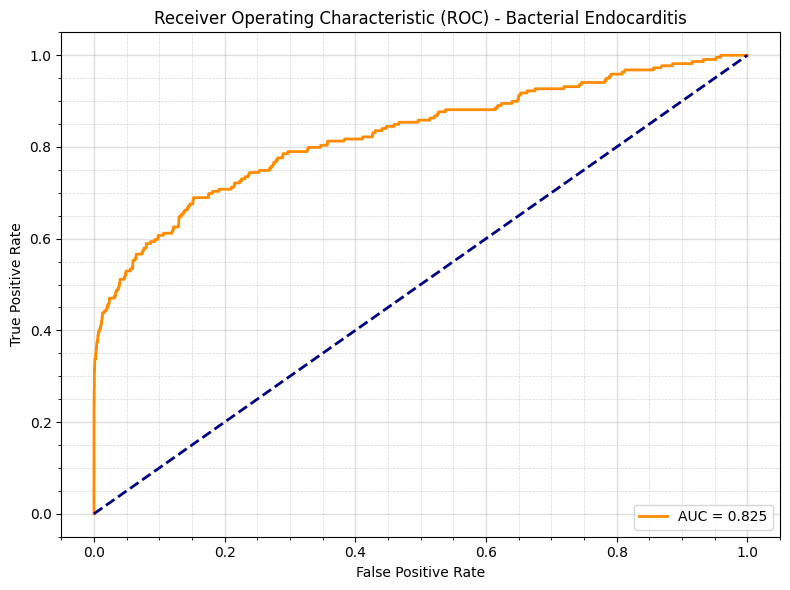

In [9]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("\n" + "="*50)
print("  PHASE 10: MODEL EVALUATION & INTERPRETABILITY")
print("="*50 + "\n")

# 1. ROC Curve Calculation
print("[EVAL] Calculating global ROC AUC across all cross-validation folds...")
fpr, tpr, _ = roc_curve(all_y, all_probs)
roc_auc = auc(fpr, tpr)
print(f"[RESULT] Final Aggregated ROC AUC: {roc_auc:.3f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) - Bacterial Endocarditis")
plt.legend(loc="lower right")

# Turn on minor ticks
plt.minorticks_on()

# Apply major grid
plt.grid(which='major', alpha=0.4, linewidth=1.0)

# Apply MORE VISIBLE minor grid (higher alpha, dashed line)
plt.grid(which='minor', alpha=0.5, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('final_roc_curve.png')
print("[PLOT] Saved ROC curve to 'final_roc_curve.png'")



[PLOT] Saved 'top_50_features_xgboost.png' to disk.


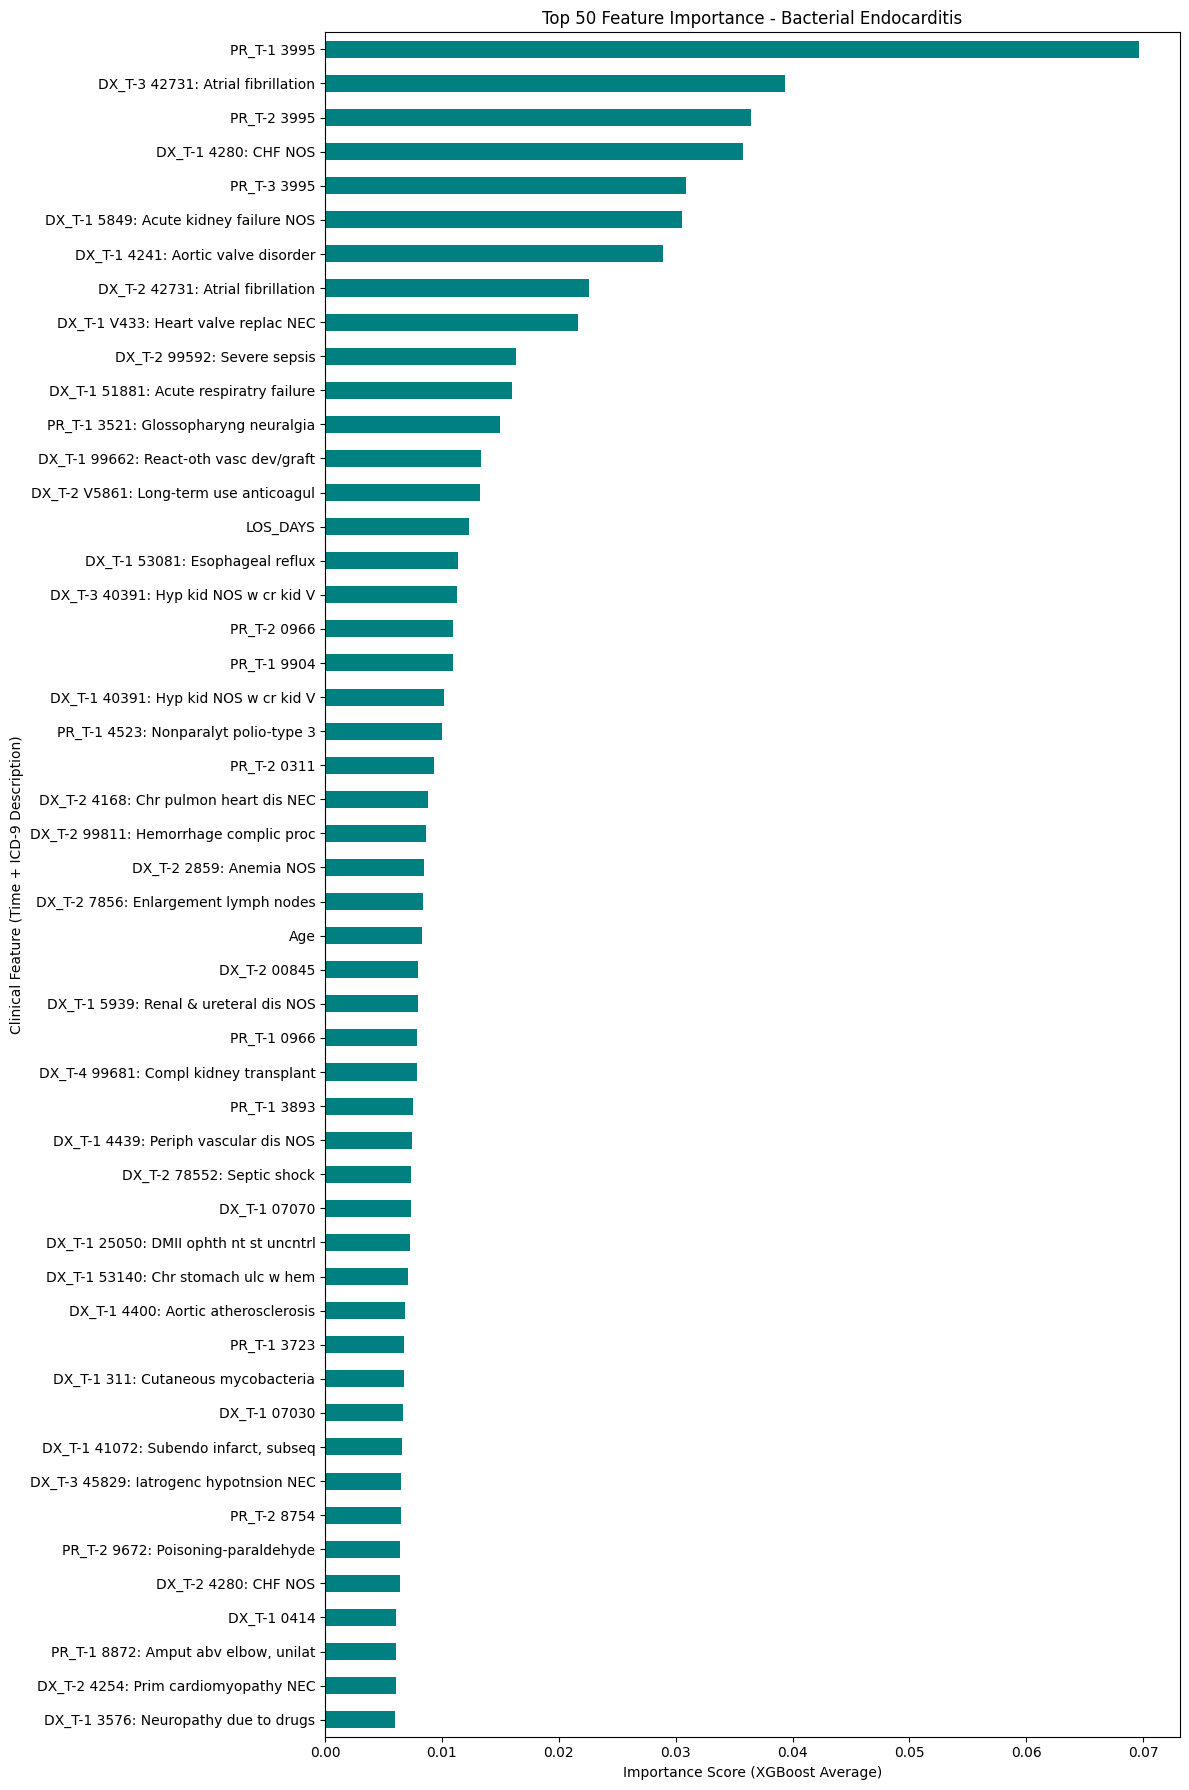

In [10]:
# TOP 50 VISUALIZATION
top_50 = master_feat_df.sort_values('XGBoost', ascending=False).head(50)

fig, ax = plt.subplots(figsize=(12, 18))
top_50.set_index('Feature')['XGBoost'].sort_values().plot(kind='barh', color='teal', ax=ax)
ax.set_title('Top 50 Feature Importance - Bacterial Endocarditis')
ax.set_xlabel('Importance Score (XGBoost Average)')
ax.set_ylabel('Clinical Feature (Time + ICD-9 Description)')
plt.tight_layout()
plt.savefig('top_50_features_xgboost.png')

print("\n[PLOT] Saved 'top_50_features_xgboost.png' to disk.")


[INTERPRET] Generating SHAP Summary Plots (This may take a moment)...


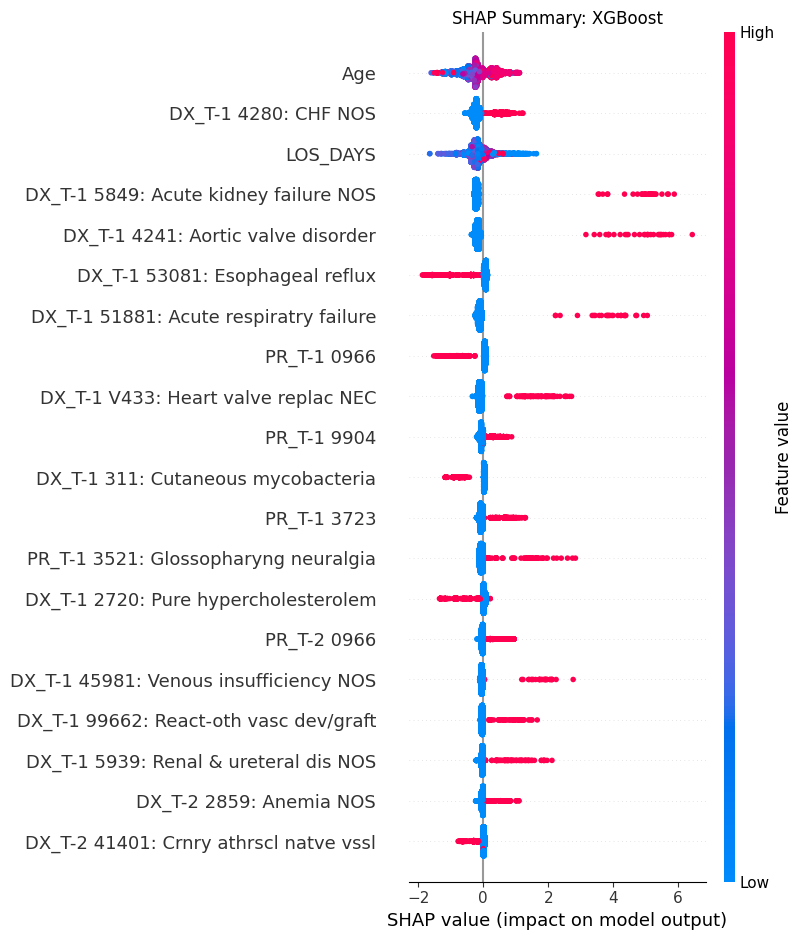

In [11]:
# 2. SHAP Summary Plots
print("\n[INTERPRET] Generating SHAP Summary Plots (This may take a moment)...")

# XGBoost SHAP Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: XGBoost")
plt.tight_layout()

shap.summary_plot(
    final_shap_df.values,
    final_X_te_df.values,
    feature_names=final_X_te_df.columns,
    show=False
)


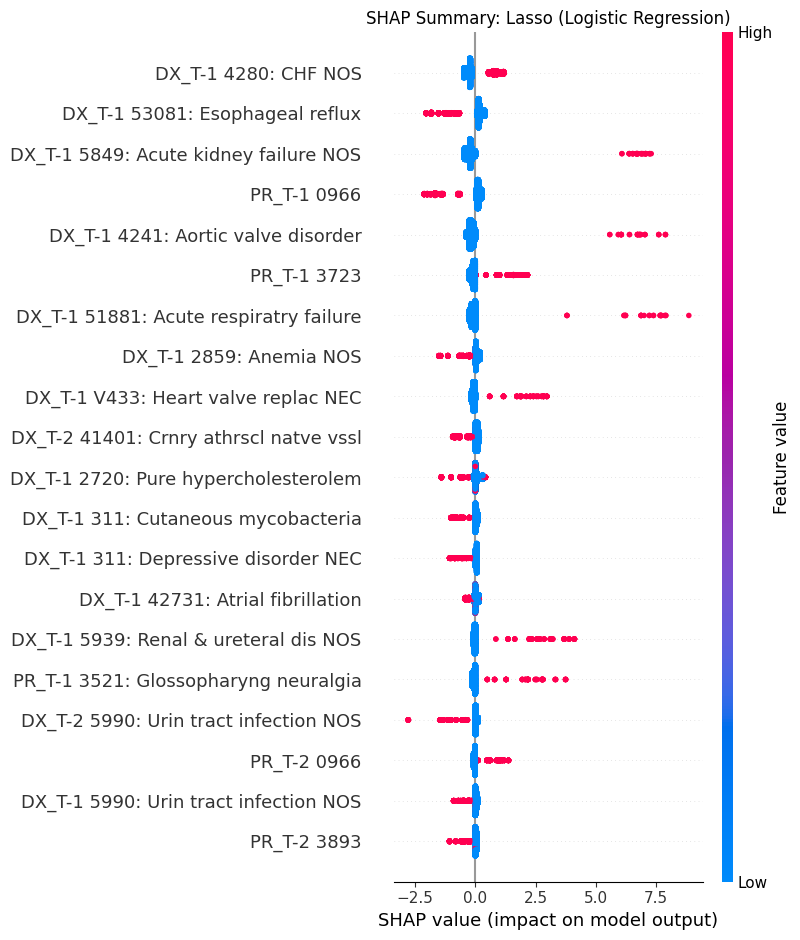


  PIPELINE COMPLETE!



In [12]:
# Lasso SHAP Plot
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary: Lasso (Logistic Regression)")
plt.tight_layout()

shap.summary_plot(
    final_shap_lasso_df.values,
    final_X_te_df.values,
    feature_names=final_X_te_df.columns
)

print("\n" + "="*50)
print("  PIPELINE COMPLETE!")
print("="*50 + "\n")